# Teoría Espectral de Gráficas

> Proyecto: Análisis espectral de la estructura y dinámica de redes financieras.



## Autor:

Dylan Ramírez

In [ ]:
# ============================================
# 1. Definición de activos y sectores
# ============================================

tickers = [
    # Tecnología
    "AAPL", "MSFT", "NVDA",

    # Finanzas
    "JPM", "GS", "BAC",

    # Energía
    "XOM", "CVX",

    # Consumo
    "KO", "PG", "WMT",

    # Industriales
    "CAT", "GE",

    # Salud
    "JNJ", "PFE",

    # Índices
    "SPY", "QQQ"
]

sector_map = {
    "AAPL": "Technology", "MSFT": "Technology", "NVDA": "Technology",
    "JPM": "Financials", "GS": "Financials", "BAC": "Financials",
    "XOM": "Energy", "CVX": "Energy",
    "KO": "Consumer", "PG": "Consumer", "WMT": "Consumer",
    "CAT": "Industrials", "GE": "Industrials",
    "JNJ": "Healthcare", "PFE": "Healthcare",
    "SPY": "Index", "QQQ": "Index"
}

In [ ]:
# ============================================
# 2. Descarga de datos
# ============================================

import yfinance as yf
import pandas as pd
import numpy as np

start_date = "2018-01-01"
end_date = "2024-12-31"

prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)["Adj Close"]

# Eliminar activos con datos incompletos
prices = prices.dropna(axis=1)

# Asegurar consistencia con sectores
tickers = list(prices.columns)
sectors = [sector_map[t] for t in tickers]

[*********************100%***********************]  17 of 17 completed


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Asegurar un orden consistente para los sectores únicos
unique_sectors = sorted(list(set(sectors)))

# Definir un colormap discreto para los sectores
# Usamos tab10 que tiene 10 colores distintivos, y resampleamos si hay más sectores
num_unique_sectors = len(unique_sectors)
global_cmap = plt.colormaps.get_cmap('tab10').resampled(max(num_unique_sectors, 10))

# Crear un diccionario que mapee cada sector a un color específico
sector_colors = {s: global_cmap(i) for i, s in enumerate(unique_sectors)}

print("Consistent sector color mapping defined.")

Consistent sector color mapping defined.


In [ ]:
# ============================================
# 3. Retornos logarítmicos
# ============================================

log_returns = np.log(prices).diff().dropna()

In [ ]:
# ============================================
# 4. Volatilidad rolling (para interpretación)
# ============================================

window_vol = 20

rolling_vol = log_returns.rolling(window_vol).std()

# Alinear dimensiones
rolling_vol = rolling_vol.dropna()
log_returns = log_returns.loc[rolling_vol.index]

Número de activos: 17
Activos utilizados: ['AAPL', 'BAC', 'CAT', 'CVX', 'GE', 'GS', 'JNJ', 'JPM', 'KO', 'MSFT', 'NVDA', 'PFE', 'PG', 'QQQ', 'SPY', 'WMT', 'XOM']

Sectores asociados:
AAPL: Technology
BAC: Financials
CAT: Industrials
CVX: Energy
GE: Industrials
GS: Financials
JNJ: Healthcare
JPM: Financials
KO: Consumer
MSFT: Technology
NVDA: Technology
PFE: Healthcare
PG: Consumer
QQQ: Index
SPY: Index
WMT: Consumer
XOM: Energy

Shape de precios: (1760, 17)
Shape de retornos: (1740, 17)
Shape de volatilidad rolling: (1740, 17)

Valores faltantes:
Precios: 0
Retornos: 0
Volatilidad: 0

Alineación temporal:
Retornos vs Volatilidad: True

Estadísticas de retornos:


Ticker,AAPL,BAC,CAT,CVX,GE,GS,JNJ,JPM,KO,MSFT,NVDA,PFE,PG,QQQ,SPY,WMT,XOM
count,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000
mean,0.001069,0.000279,0.000547,0.000249,0.000484,0.000525,0.000115,0.000531,0.000281,0.000919,0.001800,-0.000011,0.000478,0.000669,0.000488,0.000600,0.000303
std,0.019328,0.020721,0.020139,0.020493,0.025069,0.019545,0.012347,0.018693,0.012423,0.018280,0.032523,0.016018,0.012696,0.015307,0.012361,0.013782,0.019620
min,-0.137708,-0.167204,-0.154110,-0.250062,-0.164394,-0.135881,-0.105781,-0.162106,-0.101728,-0.159454,-0.207712,-0.080501,-0.091429,-0.127592,-0.115887,-0.120765,-0.130391
25%,-0.008112,-0.009620,-0.009780,-0.008400,-0.011952,-0.008892,-0.005532,-0.007885,-0.005189,-0.007668,-0.015567,-0.008585,-0.005458,-0.006440,-0.004490,-0.005657,-0.009884
50%,0.001448,0.000350,0.000710,0.000822,0.000235,0.000333,0.000349,0.000623,0.000689,0.001280,0.002816,0.000000,0.000769,0.001285,0.000774,0.000787,0.000239
75%,0.011494,0.010303,0.011625,0.009257,0.012607,0.010577,0.006026,0.009075,0.006102,0.010673,0.019698,0.008048,0.006889,0.008814,0.006685,0.007153,0.010657
max,0.113157,0.163786,0.098324,0.204904,0.137411,0.161951,0.076940,0.165620,0.062783,0.132929,0.218088,0.103055,0.113409,0.081308,0.086731,0.110723,0.119442



Estadísticas de volatilidad:


Ticker,AAPL,BAC,CAT,CVX,GE,GS,JNJ,JPM,KO,MSFT,NVDA,PFE,PG,QQQ,SPY,WMT,XOM
count,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000,1740.000000
mean,0.017525,0.018070,0.018782,0.017078,0.022695,0.017284,0.010963,0.015961,0.010707,0.016531,0.030180,0.014681,0.011083,0.013609,0.010357,0.012102,0.017532
std,0.008257,0.010150,0.007317,0.011388,0.010392,0.009118,0.005882,0.009851,0.006357,0.008223,0.012239,0.006408,0.006402,0.007153,0.006814,0.006706,0.008715
min,0.005927,0.006049,0.007376,0.006284,0.008080,0.006609,0.004492,0.004685,0.003679,0.004896,0.010622,0.004379,0.004035,0.004201,0.002993,0.003504,0.006975
25%,0.012146,0.012855,0.014153,0.011875,0.016220,0.012551,0.007800,0.010748,0.007271,0.011385,0.021301,0.010250,0.007998,0.008927,0.006306,0.007983,0.012199
50%,0.015675,0.016328,0.017212,0.014530,0.020660,0.015172,0.009688,0.013923,0.009012,0.014985,0.026662,0.013478,0.009753,0.011750,0.008765,0.010449,0.015740
75%,0.020721,0.019714,0.022173,0.018325,0.025402,0.019528,0.012187,0.017604,0.011859,0.019832,0.037303,0.017738,0.012038,0.016980,0.012653,0.013663,0.019809
max,0.068108,0.090668,0.066037,0.110071,0.087101,0.085052,0.054073,0.086093,0.054467,0.071463,0.087996,0.051577,0.059622,0.058716,0.059167,0.052135,0.069908


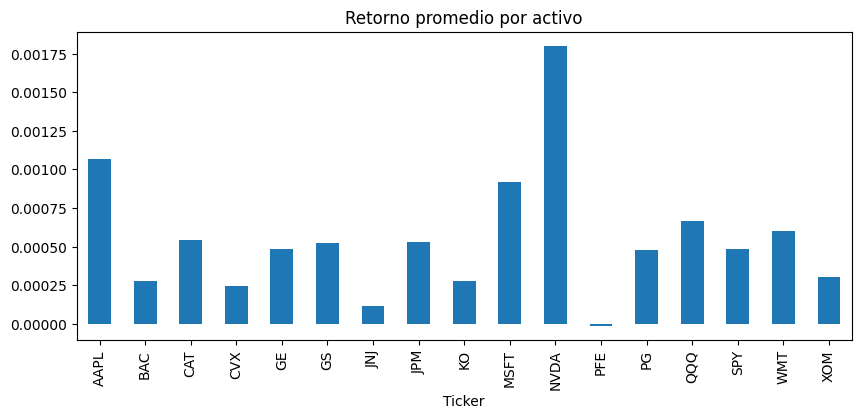

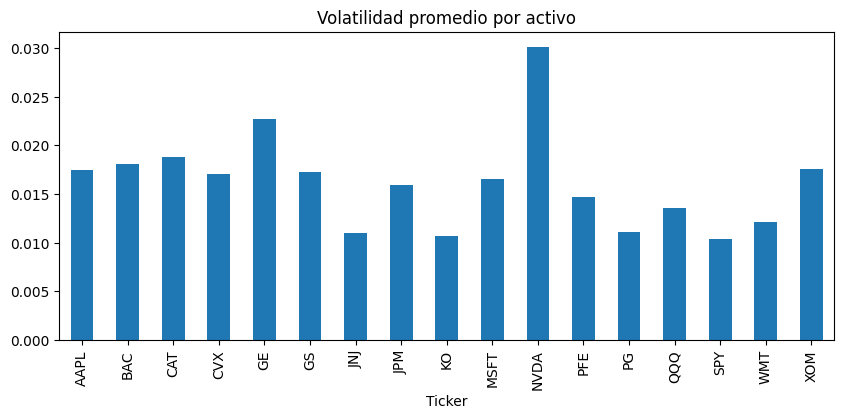

In [ ]:
# ============================================
# VERIFICACIÓN DE DATOS Y CONSISTENCIA
# ============================================

print("Número de activos:", len(tickers))
print("Activos utilizados:", tickers)
print("\nSectores asociados:")
for t, s in zip(tickers, sectors):
    print(f"{t}: {s}")

print("\nShape de precios:", prices.shape)
print("Shape de retornos:", log_returns.shape)
print("Shape de volatilidad rolling:", rolling_vol.shape)

# --------------------------------------------
# Verificar valores faltantes
# --------------------------------------------
print("\nValores faltantes:")
print("Precios:", prices.isna().sum().sum())
print("Retornos:", log_returns.isna().sum().sum())
print("Volatilidad:", rolling_vol.isna().sum().sum())

# --------------------------------------------
# Verificar alineación temporal
# --------------------------------------------
print("\nAlineación temporal:")
print("Retornos vs Volatilidad:", log_returns.index.equals(rolling_vol.index))

# --------------------------------------------
# Estadísticas básicas
# --------------------------------------------
print("\nEstadísticas de retornos:")
display(log_returns.describe())

print("\nEstadísticas de volatilidad:")
display(rolling_vol.describe())

# --------------------------------------------
# Visualización rápida (sanity check)
# --------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
log_returns.mean().plot(kind="bar")
plt.title("Retorno promedio por activo")
plt.show()

plt.figure(figsize=(10, 4))
rolling_vol.mean().plot(kind="bar")
plt.title("Volatilidad promedio por activo")
plt.show()

### Construcción del grafo


In [ ]:
# ============================================
# Construcción del grafo (snapshot estático)
# ============================================

# Ventana de tiempo (dias)
window_size = 60

R = log_returns.iloc[-window_size:]

# Correlación
corr = R.corr()

# Distancia
dist = np.sqrt(np.maximum(2 * (1 - corr), 0))

# --------------------------------------------
# Self-tuning kernel
# --------------------------------------------
k = 5  # vecinos para sigma

# sigma_i = distancia al k-ésimo vecino
sorted_dist = np.sort(dist.values, axis=1)
sigma = sorted_dist[:, k]

# Construcción de W
W = np.zeros_like(dist.values)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        if i != j:
            W[i, j] = np.exp(-(dist.values[i, j] ** 2) / (sigma[i] * sigma[j]))

# Matriz de grados
D = np.diag(W.sum(axis=1))

### Laplaciano y espectro

In [ ]:
# ============================================
# Laplaciano normalizado simétrico
# ============================================

D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D)))

L = np.eye(len(W)) - D_inv_sqrt @ W @ D_inv_sqrt

# Eigen descomposición
eigvals, eigvecs = np.linalg.eigh(L)

# Ordenar (por seguridad)
idx = np.argsort(eigvals)
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Embedding (ignoramos u1)
X = eigvecs[:, 1:3]

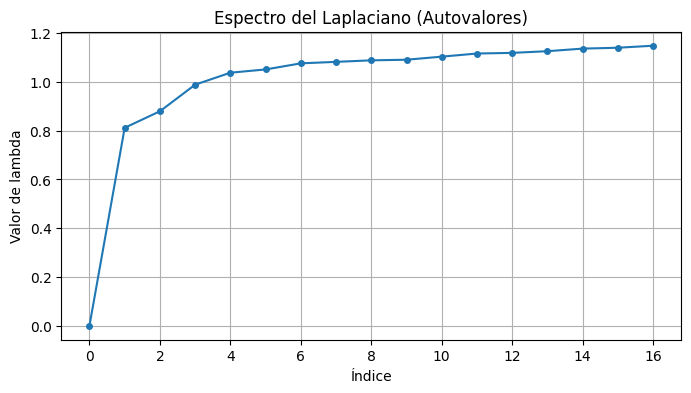

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(eigvals, 'o-', markersize=4)
plt.title("Espectro del Laplaciano (Autovalores)")
plt.xlabel("Índice")
plt.ylabel("Valor de lambda")
plt.grid(True)
plt.show()

### Visualización por sectores

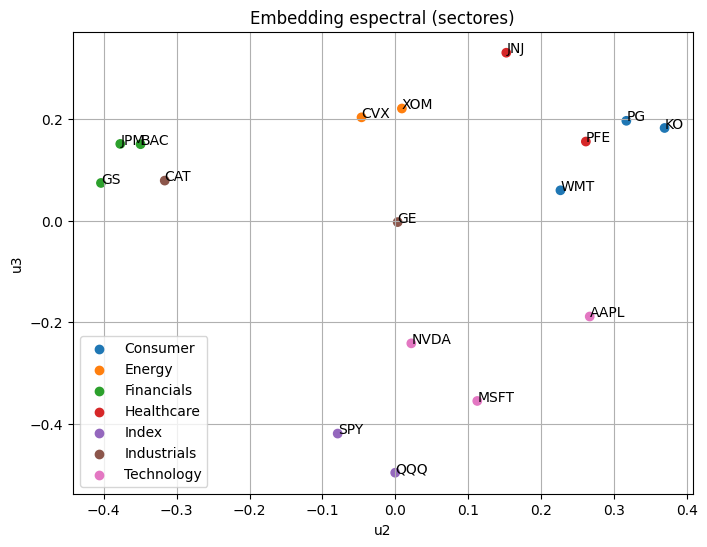

In [ ]:
# ============================================
# Embedding coloreado por sector
# ============================================

import matplotlib.pyplot as plt

# Usar el diccionario de colores definido globalmente
colors = [sector_colors[s] for s in sectors]

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=colors)

for i, t in enumerate(tickers):
    plt.text(X[i, 0], X[i, 1], t)

# Leyenda manual usando los colores consistentes
for s in unique_sectors:
    plt.scatter([], [], color=sector_colors[s], label=s)

plt.legend()
plt.title("Embedding espectral (sectores)")
plt.xlabel("u2")
plt.ylabel("u3")
plt.grid(True)
plt.show()

### Visualización por volatilidad

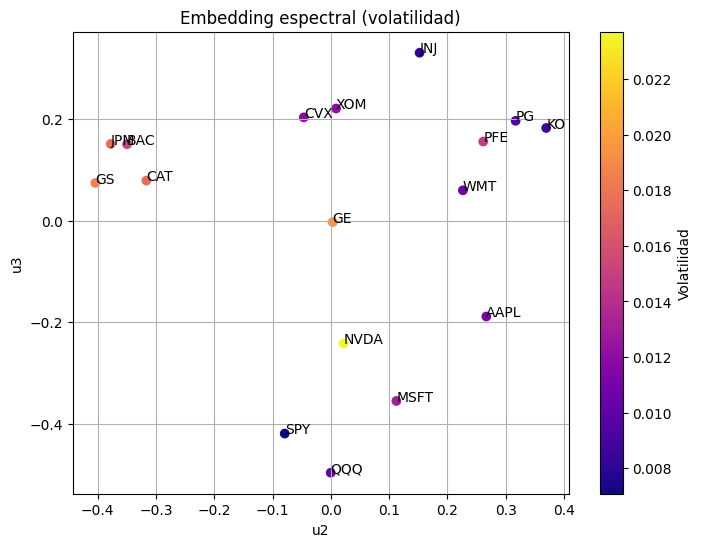

In [ ]:
# ============================================
# Embedding coloreado por volatilidad
# ============================================

# Volatilidad promedio en la misma ventana usada para el embedding
vol_snapshot = rolling_vol.loc[R.index].mean()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X[:, 0],
    X[:, 1],
    c=vol_snapshot.values,
    cmap="plasma"
)

plt.colorbar(scatter, label="Volatilidad")

for i, t in enumerate(tickers):
    plt.text(X[i, 0], X[i, 1], t)

plt.title("Embedding espectral (volatilidad)")
plt.xlabel("u2")
plt.ylabel("u3")
plt.grid(True)
plt.show()

### Eigenvectores (localización)

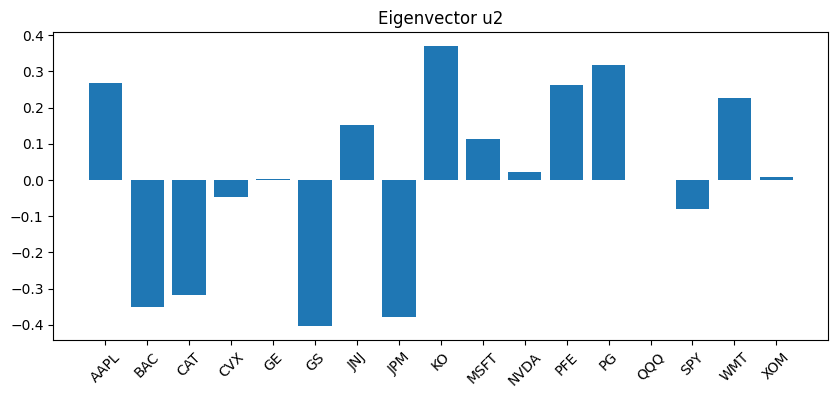

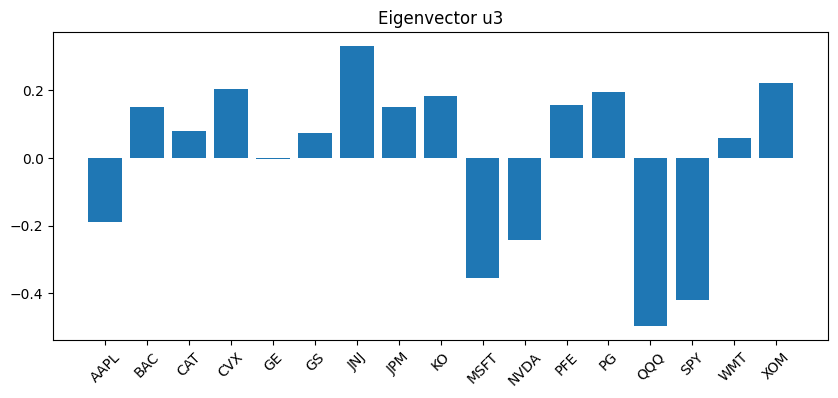

In [ ]:
# ============================================
# Visualización de eigenvectores
# ============================================

u2 = eigvecs[:, 1]
u3 = eigvecs[:, 2]

plt.figure(figsize=(10, 4))
plt.bar(tickers, u2)
plt.title("Eigenvector u2")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(tickers, u3)
plt.title("Eigenvector u3")
plt.xticks(rotation=45)
plt.show()

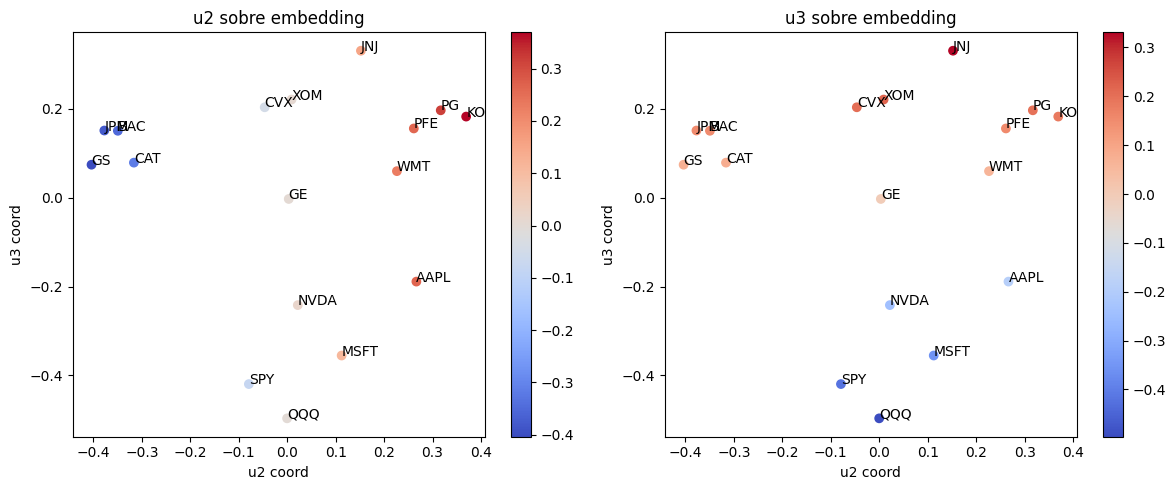

Dirichlet energy:
u2: 9.011631
u3: 9.815704

Variación local promedio:
u2: 0.065132
u3: 0.071402


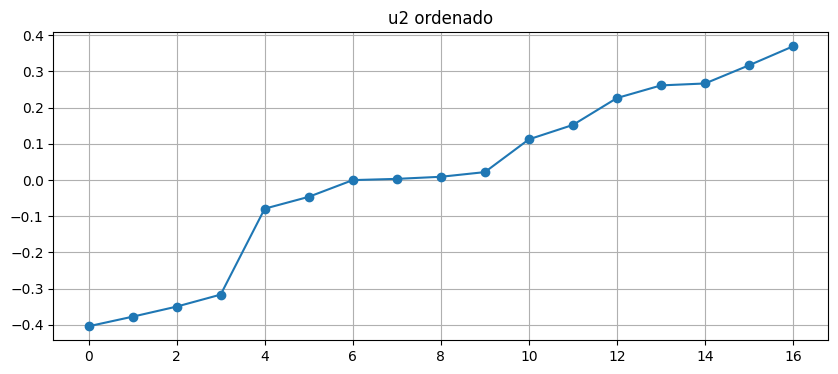

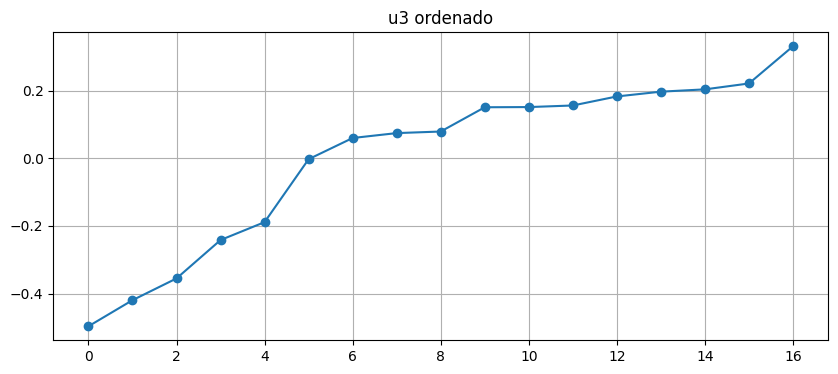

In [ ]:
# ============================================
# Visualización e interpretación de eigenvectores
# ============================================

u2 = eigvecs[:, 1]
u3 = eigvecs[:, 2]

import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------
# 1. Eigenvectores sobre el embedding
# --------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sc1 = plt.scatter(X[:, 0], X[:, 1], c=u2, cmap="coolwarm")
plt.colorbar(sc1)
for i, t in enumerate(tickers):
    plt.text(X[i, 0], X[i, 1], t)
plt.title("u2 sobre embedding")
plt.xlabel("u2 coord")
plt.ylabel("u3 coord")

plt.subplot(1, 2, 2)
sc2 = plt.scatter(X[:, 0], X[:, 1], c=u3, cmap="coolwarm")
plt.colorbar(sc2)
for i, t in enumerate(tickers):
    plt.text(X[i, 0], X[i, 1], t)
plt.title("u3 sobre embedding")
plt.xlabel("u2 coord")
plt.ylabel("u3 coord")

plt.tight_layout()
plt.show()


# --------------------------------------------
# 2. Diagnóstico cuantitativo de "suavidad"
# --------------------------------------------

def dirichlet_energy(u, W):
    energy = 0.0
    n = len(u)
    for i in range(n):
        for j in range(n):
            energy += W[i, j] * (u[i] - u[j])**2
    return energy

E_u2 = dirichlet_energy(u2, W)
E_u3 = dirichlet_energy(u3, W)

print("Dirichlet energy:")
print(f"u2: {E_u2:.6f}")
print(f"u3: {E_u3:.6f}")


# --------------------------------------------
# 3. Estadísticas de variación local
# --------------------------------------------

# diferencias entre vecinos más cercanos
from sklearn.metrics import pairwise_distances

dist_embed = pairwise_distances(X)
nearest = np.argsort(dist_embed, axis=1)[:, 1]  # vecino más cercano

local_diff_u2 = np.abs(u2 - u2[nearest])
local_diff_u3 = np.abs(u3 - u3[nearest])

print("\nVariación local promedio:")
print(f"u2: {local_diff_u2.mean():.6f}")
print(f"u3: {local_diff_u3.mean():.6f}")


# --------------------------------------------
# 4. Ordenamiento por valor (para detectar saltos)
# --------------------------------------------

sorted_u2 = np.sort(u2)
sorted_u3 = np.sort(u3)

plt.figure(figsize=(10, 4))
plt.plot(sorted_u2, marker='o')
plt.title("u2 ordenado")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(sorted_u3, marker='o')
plt.title("u3 ordenado")
plt.grid(True)
plt.show()

In [ ]:
# ============================================
# Clustering + NMI con sectores
# ============================================

from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
import numpy as np

# --------------------------------------------
# 1. Convertir sectores a etiquetas numéricas
# --------------------------------------------
unique_sectors = list(set(sectors))
sector_to_label = {s: i for i, s in enumerate(unique_sectors)}
sector_labels = np.array([sector_to_label[s] for s in sectors])

# --------------------------------------------
# 2. Clustering sobre embedding
# --------------------------------------------
k = len(unique_sectors)  # número natural de clusters

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# --------------------------------------------
# 3. Calcular NMI
# --------------------------------------------
nmi = normalized_mutual_info_score(sector_labels, cluster_labels)

print(f"NMI (clusters vs sectores): {nmi:.4f}")

NMI (clusters vs sectores): 0.7988


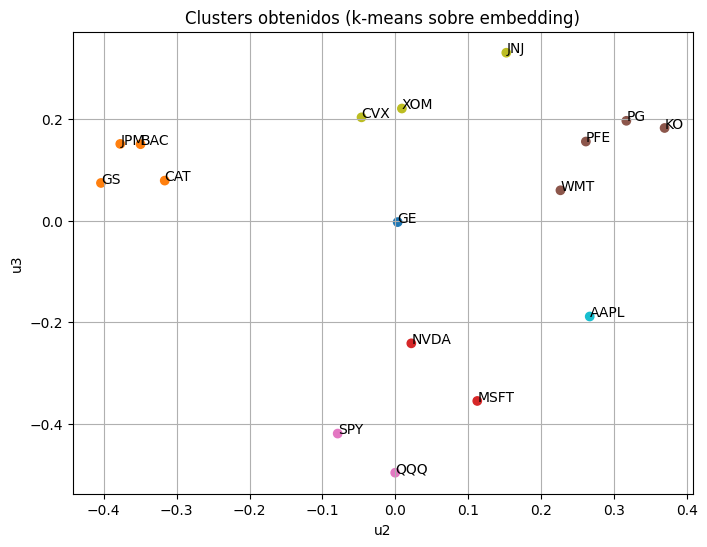

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap="tab10")

for i, t in enumerate(tickers):
    plt.text(X[i, 0], X[i, 1], t)

plt.title("Clusters obtenidos (k-means sobre embedding)")
plt.xlabel("u2")
plt.ylabel("u3")
plt.grid(True)
plt.show()

## Dinámica

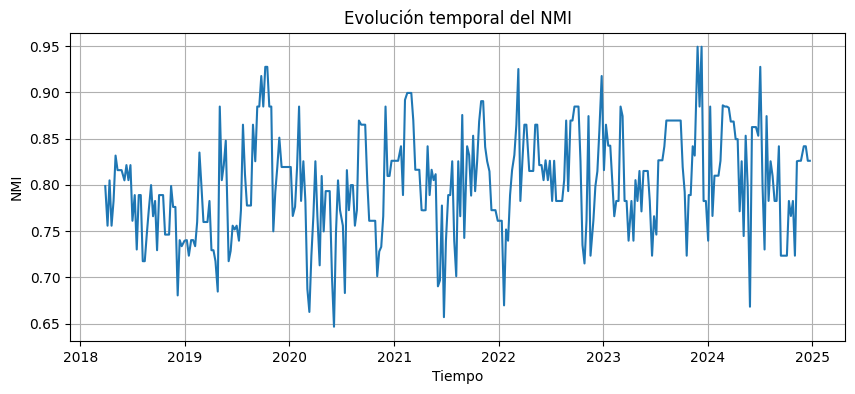

In [ ]:
# ============================================
# NMI dinámico
# ============================================

from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score

window_size = 60
step = 5

nmi_values = []
time_index = []

for start in range(0, len(log_returns) - window_size, step):

    end = start + window_size
    R = log_returns.iloc[start:end]

    # Correlación
    corr = R.corr()
    dist = np.sqrt(2 * (1 - corr))

    # Self-tuning kernel
    sorted_dist = np.sort(dist.values, axis=1)
    sigma = sorted_dist[:, 5]

    W = np.zeros_like(dist.values)
    for i in range(len(tickers)):
        for j in range(len(tickers)):
            if i != j:
                W[i, j] = np.exp(-(dist.values[i, j]**2) / (sigma[i] * sigma[j]))

    # Laplaciano
    D = np.diag(W.sum(axis=1))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D)))
    L = np.eye(len(W)) - D_inv_sqrt @ W @ D_inv_sqrt

    # Espectro
    eigvals, eigvecs = np.linalg.eigh(L)
    idx = np.argsort(eigvals)
    eigvecs = eigvecs[:, idx]

    X = eigvecs[:, 1:3]

    # Clustering
    k = len(set(sectors))
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    # NMI
    nmi = normalized_mutual_info_score(sector_labels, cluster_labels)

    nmi_values.append(nmi)
    time_index.append(R.index[-1])

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(time_index, nmi_values)
plt.title("Evolución temporal del NMI")
plt.xlabel("Tiempo")
plt.ylabel("NMI")
plt.grid(True)
plt.show()

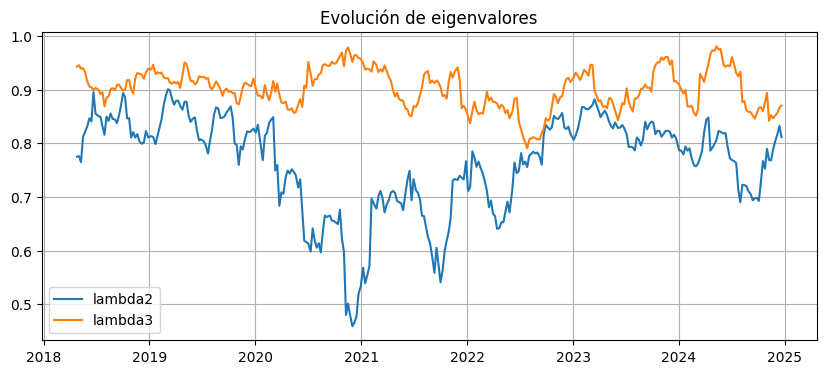

In [ ]:
# ============================================
# Evolución de eigenvalores
# ============================================

lambda2 = []
lambda3 = []

for start in range(0, len(log_returns) - window_size, step):

    end = start + window_size
    R = log_returns.iloc[start:end]

    corr = R.corr()
    dist = np.sqrt(2 * (1 - corr))

    sorted_dist = np.sort(dist.values, axis=1)
    sigma = sorted_dist[:, 5]

    W = np.zeros_like(dist.values)
    for i in range(len(tickers)):
        for j in range(len(tickers)):
            if i != j:
                W[i, j] = np.exp(-(dist.values[i, j]**2) / (sigma[i] * sigma[j]))

    D = np.diag(W.sum(axis=1))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D)))
    L = np.eye(len(W)) - D_inv_sqrt @ W @ D_inv_sqrt

    eigvals, _ = np.linalg.eigh(L)
    eigvals = np.sort(eigvals)

    lambda2.append(eigvals[1])
    lambda3.append(eigvals[2])

# Plot
plt.figure(figsize=(10, 4))
plt.plot(time_index, lambda2, label="lambda2")
plt.plot(time_index, lambda3, label="lambda3")
plt.title("Evolución de eigenvalores")
plt.legend()
plt.grid(True)
plt.show()

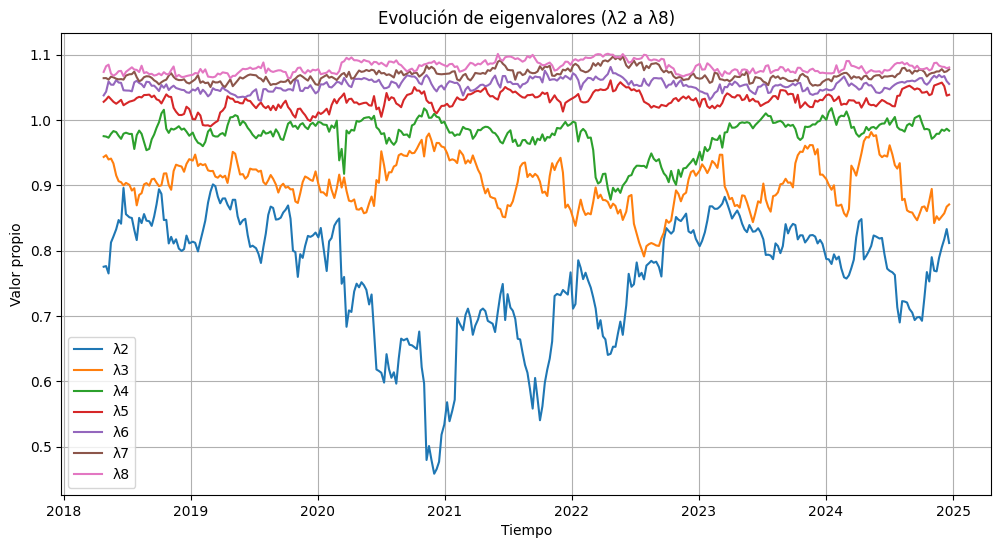

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# Evolución de eigenvalores (dinámico)
# ============================================

# Obtener el número de sectores (k)
unique_sectors = list(set(sectors))
k_sectors = len(unique_sectors)

# Lista para almacenar la evolución de los eigenvalores
# eigenvalues_evolution[i] contendrá los eigenvalores [lambda_2, ..., lambda_k_sectors+1] para cada paso de tiempo
eigenvalues_evolution = []

for start in range(0, len(log_returns) - window_size, step):

    end = start + window_size
    R = log_returns.iloc[start:end]

    corr = R.corr()
    dist = np.sqrt(2 * (1 - corr))

    sorted_dist = np.sort(dist.values, axis=1)
    sigma = sorted_dist[:, 5]

    W = np.zeros_like(dist.values)
    for i in range(len(tickers)):
        for j in range(len(tickers)):
            if i != j:
                W[i, j] = np.exp(-(dist.values[i, j]**2) / (sigma[i] * sigma[j]))

    D = np.diag(W.sum(axis=1))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D)))
    L = np.eye(len(W)) - D_inv_sqrt @ W @ D_inv_sqrt

    eigvals, _ = np.linalg.eigh(L)
    eigvals = np.sort(eigvals)

    # Recopilar eigenvalores desde lambda_2 hasta lambda_k_sectors+1
    # (índices 1 a k_sectors en un array 0-indexed)
    eigenvalues_evolution.append(eigvals[1 : k_sectors + 1])

# Convertir a un array numpy para facilitar el plotting
eigenvalues_evolution_np = np.array(eigenvalues_evolution)

# Plot
plt.figure(figsize=(12, 6))
for i in range(eigenvalues_evolution_np.shape[1]):
    plt.plot(time_index, eigenvalues_evolution_np[:, i], label=f"λ{i+2}")

plt.title(f"Evolución de eigenvalores (λ2 a λ{k_sectors+1})")
plt.xlabel("Tiempo")
plt.ylabel("Valor propio")
plt.legend()
plt.grid(True)
plt.show()

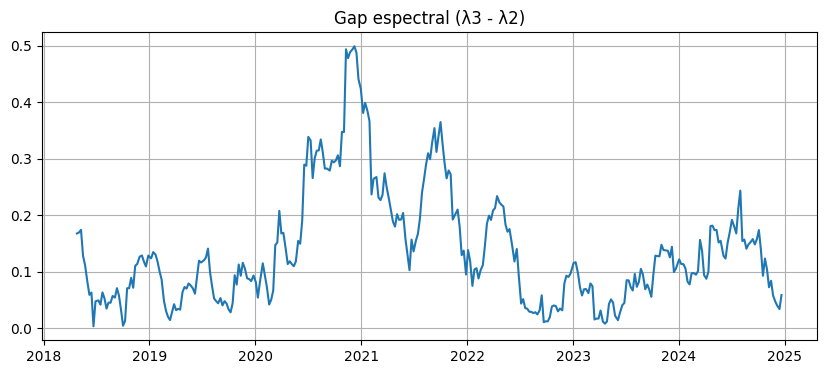

In [ ]:
gap = np.array(lambda3) - np.array(lambda2)

plt.figure(figsize=(10, 4))
plt.plot(time_index, gap)
plt.title("Gap espectral (λ3 - λ2)")
plt.grid(True)
plt.show()

In [ ]:
# ============================================
# Embeddings dinámicos
# ============================================

from scipy.linalg import orthogonal_procrustes

embeddings = []
Ws = []

for start in range(0, len(log_returns) - window_size, step):

    end = start + window_size
    R = log_returns.iloc[start:end]

    corr = R.corr()
    dist = np.sqrt(2 * (1 - corr))

    sorted_dist = np.sort(dist.values, axis=1)
    sigma = sorted_dist[:, 5]

    W = np.zeros_like(dist.values)
    for i in range(len(tickers)):
        for j in range(len(tickers)):
            if i != j:
                W[i, j] = np.exp(-(dist.values[i, j]**2) / (sigma[i] * sigma[j]))

    D = np.diag(W.sum(axis=1))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D)))
    L = np.eye(len(W)) - D_inv_sqrt @ W @ D_inv_sqrt

    eigvals, eigvecs = np.linalg.eigh(L)
    idx = np.argsort(eigvals)
    eigvecs = eigvecs[:, idx]

    X = eigvecs[:, 1:3]

    embeddings.append(X)
    Ws.append(W)

In [ ]:
# ============================================
# Alineación de embeddings
# ============================================

aligned_embeddings = [embeddings[0]]

for t in range(1, len(embeddings)):
    X_prev = aligned_embeddings[-1]
    X_curr = embeddings[t]

    R_opt, _ = orthogonal_procrustes(X_curr, X_prev)
    X_aligned = X_curr @ R_opt

    aligned_embeddings.append(X_aligned)

In [ ]:
# ============================================
# Construcción de k-NN graph
# ============================================

k_nn = 4

def knn_edges(W, k):
    edges = []
    for i in range(W.shape[0]):
        idx = np.argsort(W[i])[::-1][1:k+1]
        for j in idx:
            edges.append((i, j))
    return edges

In [ ]:
# ============================================
# Animación del grafo dinámico (corregida)
# ============================================

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt
import numpy as np

# Increase the animation embed limit to allow larger animations
# plt.rcParams['animation.embed_limit'] = 50.0 # set to 50 MB (default is 20 MB) - Puedes comentar esta línea si vas a guardar a archivo

# --------------------------------------------
# Preparación
# --------------------------------------------

aligned_np = np.array(aligned_embeddings)

# Usar el diccionario de colores definido globalmente
colors = [sector_colors[s] for s in sectors]

fig, ax = plt.subplots(figsize=(7, 7))

# Get initial coordinates for scatter and text
initial_coords = aligned_np[0]

# Scatter inicial
scatter = ax.scatter(initial_coords[:, 0], initial_coords[:, 1], c=colors)

# Textos
texts = [ax.text(initial_coords[i, 0], initial_coords[i, 1], t) for i, t in enumerate(tickers)]

# Límites fijos (MUY IMPORTANTE)
ax.set_xlim(np.min(aligned_np[:, :, 0]) - 0.1,
            np.max(aligned_np[:, :, 0]) + 0.1)

# Corrección: Asegúrate de que el límite superior del eje Y use las coordenadas Y, no las X.
ax.set_ylim(np.min(aligned_np[:, :, 1]) - 0.1,
            np.max(aligned_np[:, :, 1]) + 0.1)

ax.grid()

# Inicializar líneas (aristas)
lines = []

def update(frame):
    coords = aligned_np[frame]
    W = Ws[frame]

    # Actualizar nodos
    scatter.set_offsets(coords)

    # Actualizar textos
    for i, text in enumerate(texts):
        text.set_position((coords[i, 0], coords[i, 1]))

    # Eliminar líneas anteriores
    for line in lines:
        line.remove()
    lines.clear()

    # Dibujar nuevas aristas
    edges = knn_edges(W, k_nn)

    for i, j in edges:
        weight = W[i, j]

        linewidth = 0.5 + 3.5 * weight

        same_sector = sectors[i] == sectors[j]
        edge_color = colors[i] if same_sector else 'gray'

        line, = ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            linewidth=linewidth,
            color=edge_color,
            alpha=0.45
        )

        lines.append(line)

    ax.set_title(f"Grafo dinámico\n{time_index[frame].date()}")

    return scatter, *lines

anim = FuncAnimation(
    fig,
    update,
    frames=len(aligned_np),
    interval=600
)

plt.close(fig)

# Para guardar como MP4 (requiere ffmpeg):
anim.save('dynamic_graph.mp4', writer='ffmpeg', fps=10)

# HTML(anim.to_jshtml()) # Comenta esta línea si vas a guardar a un archivo.

In [ ]:
from moviepy.editor import VideoFileClip

def convertir_video_a_gif(input_path, output_path, fps=10):
    # Cargar el video
    clip = VideoFileClip(input_path)
    # Convertir a gif
    clip.write_gif(output_path, fps=fps)

# Uso:
convertir_video_a_gif('dynamic_graph.mp4', 'dynamic_graph.gif', fps=10)

MoviePy - Building file dynamic_graph.gif with imageio.


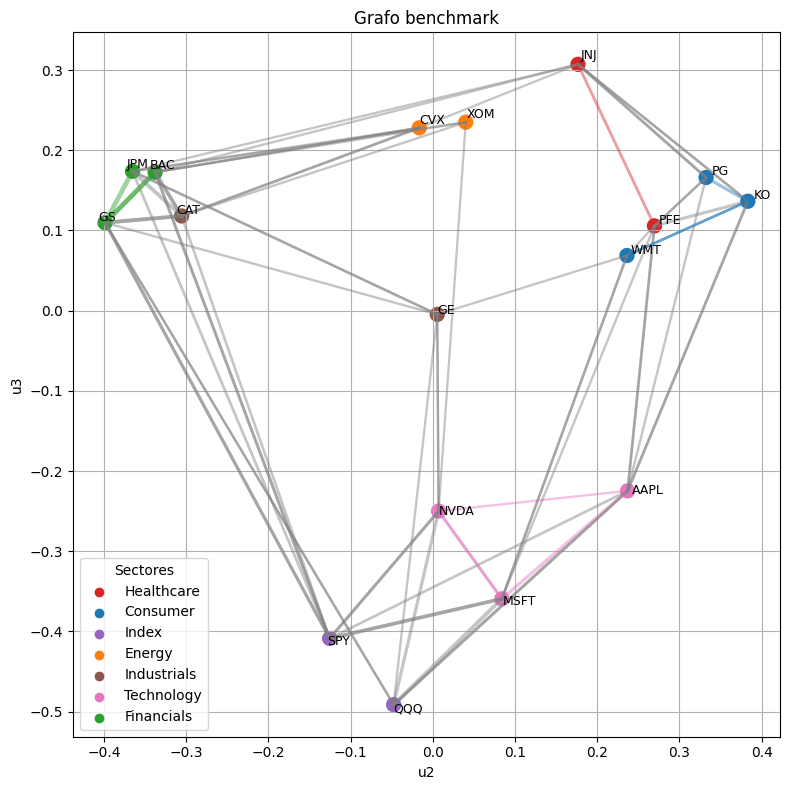

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

coords = X # Coordenadas de los nodos desde el embedding estático
W_static = W # Matriz de adyacencia desde el cálculo estático

# Usar el diccionario de colores definido globalmente
colors_static = [sector_colors[s] for s in sectors]

fig, ax = plt.subplots(figsize=(8, 8))

# Plotear los nodos
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=colors_static, s=100) # Aumentar tamaño para visibilidad

# Añadir etiquetas de tickers
for i, t in enumerate(tickers):
    ax.text(coords[i, 0] * 1.02, coords[i, 1] * 1.02, t, fontsize=9)

# Dibujar aristas
edges = knn_edges(W_static, k_nn)

lines = []
for i, j in edges:
    weight = W_static[i, j]
    linewidth = 0.5 + 3.5 * weight

    same_sector = sectors[i] == sectors[j]
    edge_color = colors_static[i] if same_sector else 'gray'

    line, = ax.plot(
        [coords[i, 0], coords[j, 0]],
        [coords[i, 1], coords[j, 1]],
        linewidth=linewidth,
        color=edge_color,
        alpha=0.45
    )
    lines.append(line)

# Leyenda manual para los sectores
for s in unique_sectors:
    ax.scatter([], [], color=sector_colors[s], label=s)

ax.legend(title="Sectores")
ax.set_title("Grafo benchmark")
ax.set_xlabel("u2")
ax.set_ylabel("u3")
ax.grid(True)
plt.tight_layout()
plt.show()